In [35]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error


  image_gray.shape = (400, 600)
  image_gray[0,0] = 23


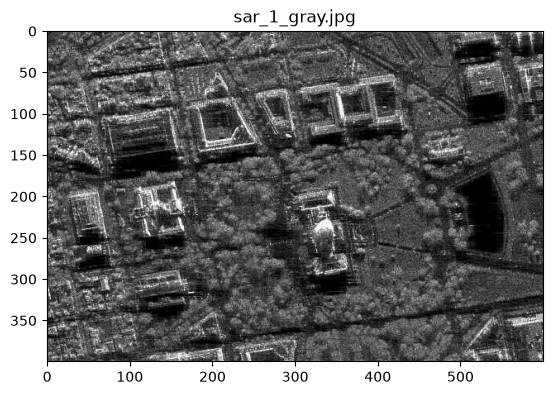

In [36]:
# 1. Загружаем изображение
image_gray = cv2.imread(r"C:\Users\arago\Desktop\leaning\home\sar_1_gray.jpg",cv2.IMREAD_GRAYSCALE)

print("  image_gray.shape =", image_gray.shape)
print("  image_gray[0,0] =", image_gray[0, 0])

plt.imshow(image_gray, cmap='gray')
plt.title('sar_1_gray.jpg')
plt.show()

  сумма бинов = 240000
  пикселей    = 240000


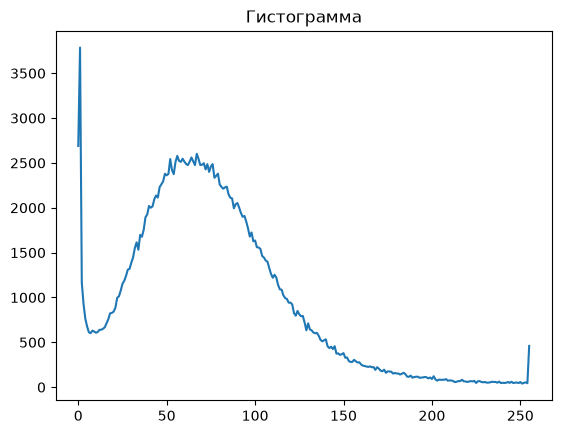

In [38]:
# 2.гистограмма
histSize = 256
histRange = (0, 256)
accumulate = False

gray_hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)

print("  сумма бинов =", int(gray_hist.sum()))
print("  пикселей    =", image_gray.size)

plt.plot(gray_hist)
plt.title('Гистограмма')
plt.show()


  γ = 0.5: mean = 29.07
  γ = 2.0: mean = 130.56


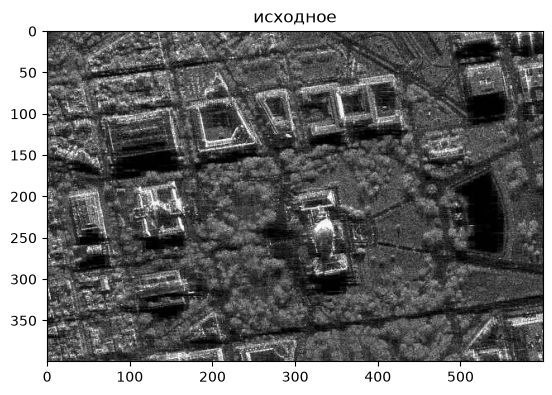

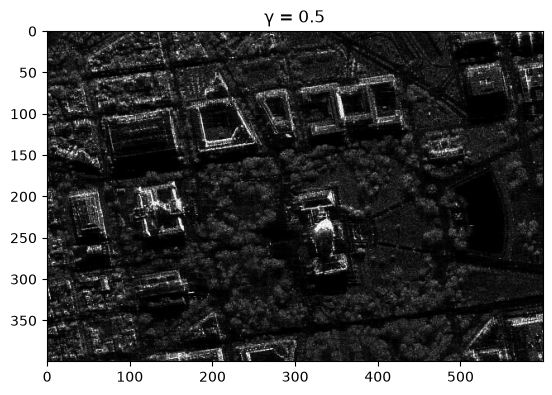

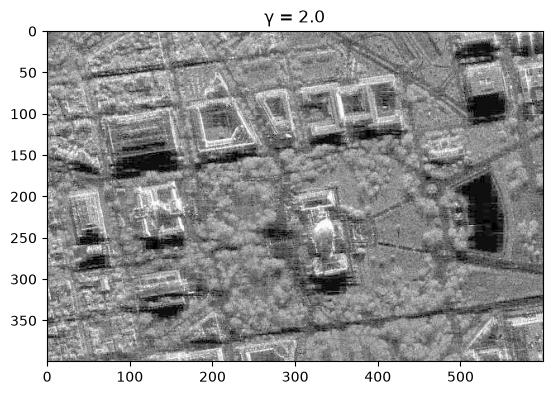

In [39]:
# 3. Реализация гамма-коррекции
def gamma_correction(img, gamma):
    table = np.array([((i / 255.0) ** (1.0 / gamma)) * 255
                      for i in np.arange(256)]).astype('uint8')
    return cv2.LUT(img, table)

gamma_low, gamma_high = 0.5, 2.0
img_gamma_low  = gamma_correction(image_gray, gamma_low)
img_gamma_high = gamma_correction(image_gray, gamma_high)

print(f"  γ = {gamma_low}: mean = {img_gamma_low.mean():.2f}")
print(f"  γ = {gamma_high}: mean = {img_gamma_high.mean():.2f}")

plt.imshow(image_gray, cmap='gray');     plt.title('исходное');        plt.show()
plt.imshow(img_gamma_low, cmap='gray');  plt.title(f'γ = {gamma_low}');  plt.show()
plt.imshow(img_gamma_high, cmap='gray'); plt.title(f'γ = {gamma_high}'); plt.show()

In [41]:
# 4. Сравнение: MSE и SSIM
mse_low  = mean_squared_error(image_gray, img_gamma_low)
ssim_low = structural_similarity(image_gray, img_gamma_low)

mse_high  = mean_squared_error(image_gray, img_gamma_high)
ssim_high = structural_similarity(image_gray, img_gamma_high)

print(f"  γ = {gamma_low}:  MSE = {mse_low:.4f} | SSIM = {ssim_low:.4f}")
print(f"  γ = {gamma_high}: MSE = {mse_high:.4f} | SSIM = {ssim_high:.4f}")

  γ = 0.5:  MSE = 2383.7636 | SSIM = 0.5270
  γ = 2.0: MSE = 3250.4291 | SSIM = 0.7875


  eq_gray : mean = 127.03, std = 74.27
  результат: mean = 123.12, std = 65.30


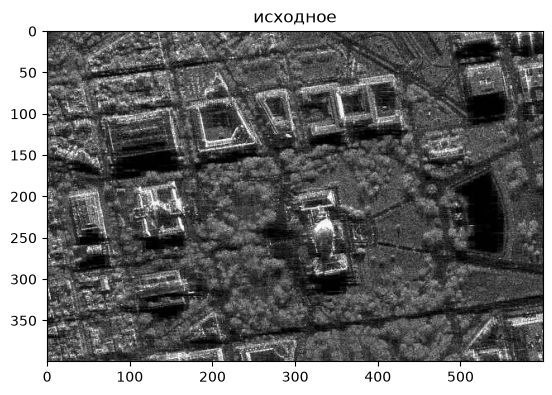

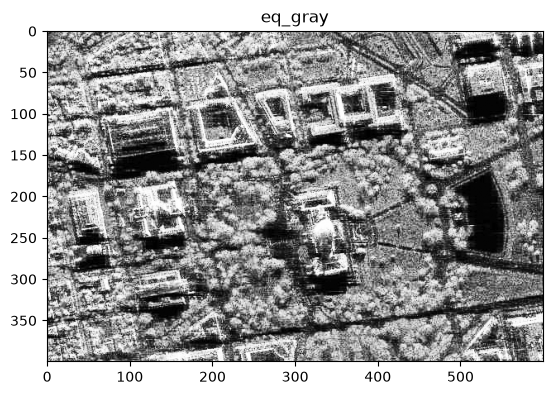

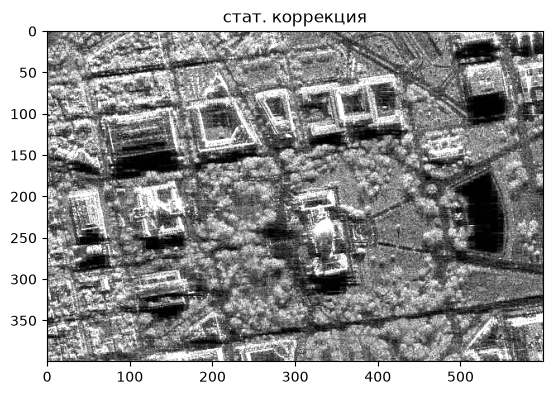

In [42]:
# 5. Статистическая цветокоррекция на основе статистики eq_gray
eq_gray = cv2.equalizeHist(image_gray)

mean_ref, std_ref = eq_gray.mean(), eq_gray.std()
mean_src, std_src = image_gray.mean(), image_gray.std()

image_stat = (image_gray.astype(np.float32) - mean_src) * (std_ref / std_src) + mean_ref
image_stat = np.clip(image_stat, 0, 255).astype('uint8')

print(f"  eq_gray : mean = {mean_ref:.2f}, std = {std_ref:.2f}")
print(f"  результат: mean = {image_stat.mean():.2f}, std = {image_stat.std():.2f}")

plt.imshow(image_gray, cmap='gray'); plt.title('исходное');        plt.show()
plt.imshow(eq_gray,    cmap='gray'); plt.title('eq_gray');         plt.show()
plt.imshow(image_stat, cmap='gray'); plt.title('стат. коррекция'); plt.show()

  порог = 50: белых = 169178


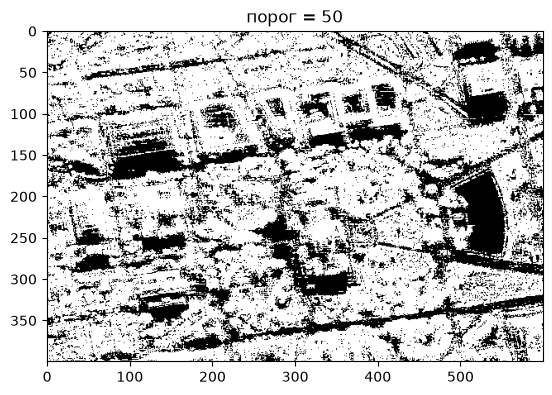

  порог = 100: белых = 55653


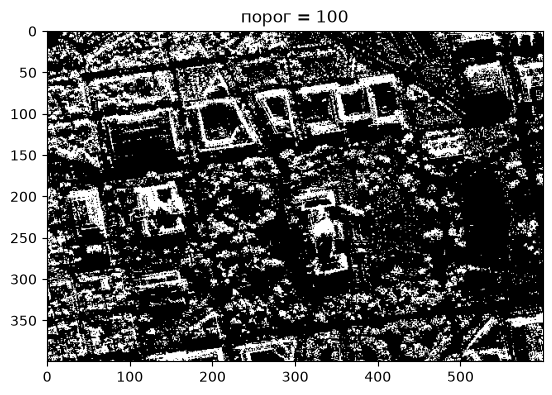

  порог = 150: белых = 13083


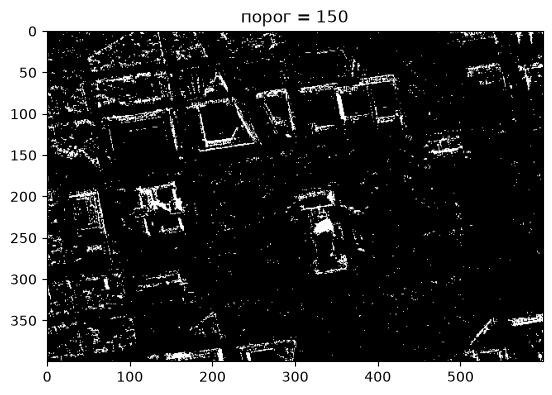

  порог = 200: белых = 3830


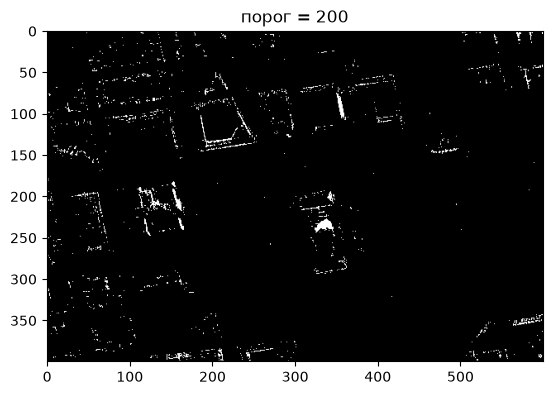

In [43]:
# 6. Пороговая фильтрация с различными параметрами (аналогично файлу)
thresholds = [50, 100, 150, 200]

for t in thresholds:
    _, thresh = cv2.threshold(image_gray, t, 255, cv2.THRESH_BINARY)
    print(f"  порог = {t}: белых = {int((thresh == 255).sum())}")

    plt.imshow(thresh, cmap='gray')
    plt.title(f'порог = {t}')
    plt.show()